# Лабораторная работа №6. Квантовое распределение ключей

КБ-211 Коренев Денис

## Задание

Реализовать и исследовать два протокола квантового распределения ключей (КРК):

1. **Модифицированный протокол Ло–Чау** — использует ЭПР-пары (запутанные состояния Белла) для установки секретного ключа с обнаружением перехватчика.
2. **Протокол на основе CSS-кода** — использует квантовый код Стина $[7,1,3]$ (CSS-код) для защищённой передачи ключевого бита.

Для каждого протокола необходимо:
- реализовать квантовую схему и промоделировать передачу ключа,
- проверить корректность при отсутствии и наличии подслушивания (атака «перехват–повтор»),
- исследовать зависимость вероятности обнаружения перехватчика от числа атакованных кубитов,
- провести статистическое тестирование сгенерированного ключа.

In [21]:
# ── Параметры протокола ────────────────────────────────────────
n = 7   # число ЭПР-пар (кубитов данных) в протоколе Ло–Чау
m = 1   # число ключевых битов в протоколе CSS
t = 1   # порог числа ошибок (параметр кода Стина: t=1 ⟹ расстояние d=3)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from quantumz import initq, H, X, Y, Z, CX, CZ, measure, multi_measure, common

# ── Вспомогательные функции рисования ──────────

def draw_gate(ax, x, y, label, w=0.5, h=0.4, color='white', ec='black', fontsize=9):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle="square,pad=0.02",
                                   facecolor=color, edgecolor=ec, linewidth=1.2, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize, zorder=4)

def draw_cnot(ax, x, ctrl, tgt):
    ax.plot([x, x], [ctrl, tgt], 'k-', lw=1.2, zorder=2)
    ax.plot(x, ctrl, 'ko', ms=6, zorder=3)
    circle = plt.Circle((x, tgt), 0.18, color='white', ec='black', lw=1.2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, tgt, '⊕', ha='center', va='center', fontsize=10, zorder=4)

def draw_measure(ax, x, y):
    rect = mpatches.FancyBboxPatch((x - 0.28, y - 0.22), 0.56, 0.44,
                                   boxstyle="square,pad=0.02",
                                   facecolor='lightyellow', edgecolor='black', lw=1.2, zorder=3)
    ax.add_patch(rect)
    arc = mpatches.Arc((x, y - 0.05), 0.3, 0.2, angle=0, theta1=0, theta2=180,
                       color='black', lw=1, zorder=4)
    ax.add_patch(arc)
    ax.annotate('', xy=(x + 0.12, y + 0.05), xytext=(x, y - 0.05),
                arrowprops=dict(arrowstyle='->', color='black', lw=1), zorder=4)

print("Библиотеки загружены.")

Библиотеки загружены.


## Теория

### ЭПР-пары и состояния Белла

Состояние Белла $|\beta_{00}\rangle$ (ЭПР-пара) — максимально запутанное двухкубитное состояние:

$$|\beta_{00}\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Создаётся применением вентиля Адамара к первому кубиту с последующим CNOT:

$$|00\rangle \xrightarrow{H \otimes I} \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes |0\rangle \xrightarrow{\text{CNOT}} \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Ключевое свойство: измерение одного кубита мгновенно определяет состояние второго.

### Протокол Ло–Чау (Lo–Chau)

Обобщение протокола BB84 с использованием ЭПР-пар:

1. **Алиса** создаёт $2n$ ЭПР-пар, хранит у себя первые кубиты, отправляет Бобу вторые.
2. По открытому каналу выбираются $n$ пар для **проверки** (тест Белла) и $n$ пар для **ключа**.
3. **Боб** случайно применяет H к своим кубитам проверочных пар (базис $X$ или $Z$).
4. Алиса измеряет свои проверочные кубиты, сравнивает с Бобом — если ошибок $> t$, протокол прерывается (обнаружен Ева).
5. Ключ формируется из $n$ оставшихся пар.

Принцип обнаружения Евы: перехват кубита и его повторная отправка (атака «перехват–повтор») вносит ошибку $25\%$ в каждую атакованную пару.

### Протокол CSS-КРК

Использует квантовый код Стина $[7,1,3]$ — CSS-код с $d=3$, исправляющий $t=1$ ошибку:

1. **Алиса** кодирует ключевой бит логическим состоянием $|\bar{0}\rangle$ или $|\bar{1}\rangle$ кода Стина.
2. Отправляет закодированное состояние Бобу.
3. **Боб** измеряет синдромы Z и X-стабилизаторов, применяет коррекцию, декодирует ключевой бит.

Матрица проверки чётности кода Стина:
$$H_z = H_x = \begin{pmatrix} 1&0&1&0&1&0&1 \\ 0&1&1&0&0&1&1 \\ 0&0&0&1&1&1&1 \end{pmatrix}$$

ЭПР-пара |β₀₀⟩:
  |00>: 0.7071+0.0000j
  |11>: 0.7071+0.0000j


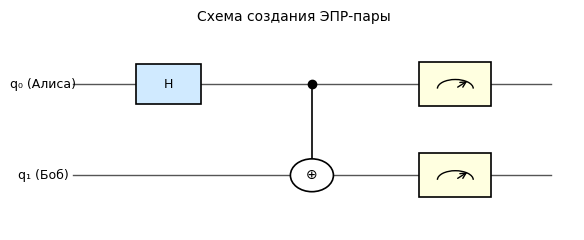

In [23]:
# ── ЭПР-пара ──────────────────────────────────────────────────

def create_epr_pair():
    """Создаёт состояние Белла |β₀₀⟩ = (|00⟩ + |11⟩)/√2."""
    q = initq(2)
    q = H(q, 0)
    q = CX(q, [0], 1)
    return q

# Проверка
epr = create_epr_pair()
print("ЭПР-пара |β₀₀⟩:")
for ket, amp in sorted(epr.items()):
    print(f"  {ket}: {amp:.4f}")

# Схема создания ЭПР-пары
fig, ax = plt.subplots(figsize=(6, 2.5))

wires = [1.0, 0.0]
labels = ['q₀ (Алиса)', 'q₁ (Боб)']
x_end = 4.5

for y, lbl in zip(wires, labels):
    ax.plot([0.5, x_end], [y, y], color='#555', lw=1.0, zorder=1)
    ax.text(0.25, y, lbl, ha='center', va='center', fontsize=9)

draw_gate(ax, 1.3, 1.0, 'H', color='#d0eaff')
draw_cnot(ax, 2.5, 1.0, 0.0)
draw_measure(ax, 3.7, 1.0)
draw_measure(ax, 3.7, 0.0)

ax.set_xlim(0, x_end + 0.2)
ax.set_ylim(-0.6, 1.6)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Схема создания ЭПР-пары', fontsize=10, pad=6)
plt.tight_layout()
plt.savefig('output/epr_circuit.png', dpi=120, bbox_inches='tight')
plt.show()

## Протокол Ло–Чау

### Шаги протокола

| № | Участник | Действие |
|---|---------|---------|
| 1 | Алиса | Создаёт $2n$ ЭПР-пар; хранит «левые» кубиты, отправляет «правые» Бобу |
| 2 | Боб | Получает $2n$ кубитов |
| 3 | Открытый канал | Выбираются $n$ пар для **проверки** и $n$ для **ключа** |
| 4 | Боб | К проверочным кубитам применяет H с вероятностью $\frac{1}{2}$ (выбор базиса) |
| 5 | Боб | Измеряет свои проверочные кубиты, сообщает Алисе базисы и результаты |
| 6 | Алиса | Измеряет свои проверочные кубиты в тех же базисах, вычисляет долю ошибок |
| 7 | Обе | Если ошибок $> t$ — **прервать** (обнаружен перехватчик) |
| 8 | Алиса и Боб | Измеряют ключевые пары в базисе Z → сырой ключ |
| 9 | Обе | Классическая коррекция чётности ключа (XOR) |

**Атака «перехват–повтор» (Ева):** Ева перехватывает кубит Боба, измеряет его (коллапс состояния), затем отправляет результат Бобу. Это вносит ошибку $25\%$ на атакованную пару, так как проекция разрушает запутанность.

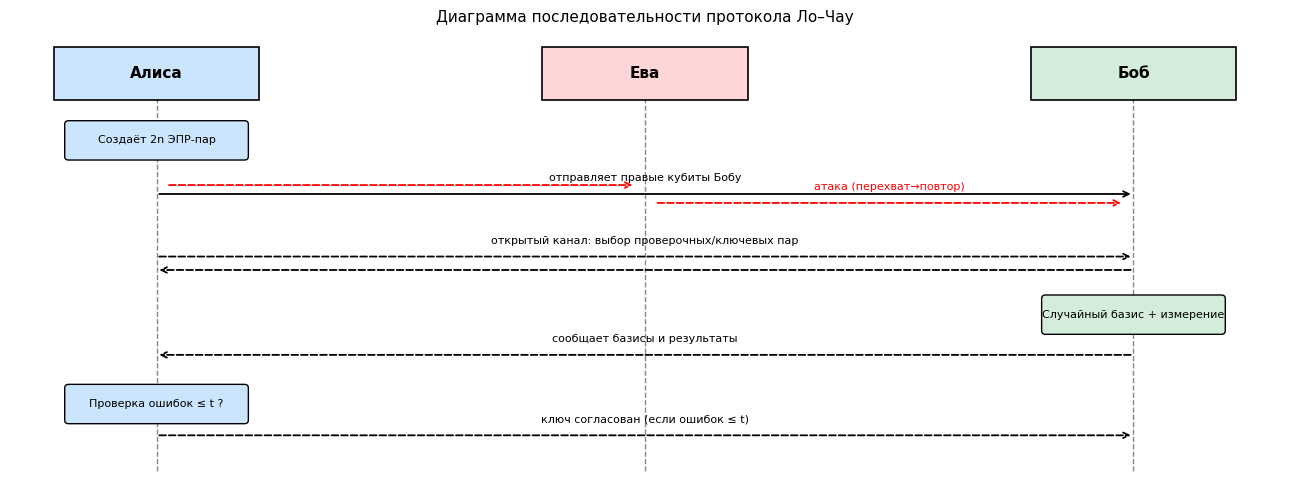

In [37]:
# ── Диаграмма последовательности протокола Ло–Чау ─────────────

fig, ax = plt.subplots(figsize=(13, 5))

# Три «дорожки»: Алиса=0, Ева=1, Боб=2
lanes = {'Алиса': 0, 'Ева': 1, 'Боб': 2}
lane_x = {0: 1.5, 1: 6.5, 2: 11.5}
colors = {'Алиса': '#cce5ff', 'Ева': '#ffd6d6', 'Боб': '#d4edda'}

for name, idx in lanes.items():
    x = lane_x[idx]
    ax.add_patch(mpatches.FancyBboxPatch((x - 1.0, 4.3), 2.0, 0.5,
                 boxstyle="square,pad=0.05", facecolor=colors[name],
                 edgecolor='black', lw=1.2, zorder=3))
    ax.text(x, 4.55, name, ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    ax.plot([x, x], [0.1, 4.3], color='#888', lw=1.0, ls='--', zorder=1)

def seq_arrow(ax, y, x_from, x_to, label, color='black', style='->', ls='-'):
    ax.annotate('', xy=(x_to, y), xytext=(x_from, y),
                arrowprops=dict(arrowstyle=style, color=color, lw=1.3,
                                linestyle=ls, connectionstyle='arc3,rad=0'))
    mx = (x_from + x_to) / 2
    ax.text(mx, y + 0.12, label, ha='center', va='bottom', fontsize=8, color=color)

def seq_action(ax, x, y, label, color='#f0f0f0'):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.9, y - 0.18), 1.8, 0.36,
                 boxstyle="round,pad=0.04", facecolor=color, edgecolor='black', lw=1.0, zorder=3))
    ax.text(x, y, label, ha='center', va='center', fontsize=8, zorder=4)

# Шаг 1: Алиса создаёт ЭПР
seq_action(ax, lane_x[0], 3.8, 'Создаёт 2n ЭПР-пар', '#cce5ff')
# Шаг 2: Алиса → Боб (правые кубиты)
seq_arrow(ax, 3.2, lane_x[0], lane_x[2], 'отправляет правые кубиты Бобу')
# Ева перехватывает
seq_arrow(ax, 3.3, lane_x[0] + 0.1, lane_x[1] - 0.1, '', color='red', ls='--')
seq_arrow(ax, 3.1, lane_x[1] + 0.1, lane_x[2] - 0.1, 'атака (перехват→повтор)', color='red', ls='--')
# Шаг 3: открытый канал
seq_arrow(ax, 2.5, lane_x[0], lane_x[2], 'открытый канал: выбор проверочных/ключевых пар', ls='--')
seq_arrow(ax, 2.35, lane_x[2], lane_x[0], '', ls='--')
# Шаг 4-5: Боб измеряет
seq_action(ax, lane_x[2], 1.85, 'Случайный базис + измерение', '#d4edda')
seq_arrow(ax, 1.4, lane_x[2], lane_x[0], 'сообщает базисы и результаты', ls='--')
# Шаг 6-7: Алиса проверяет
seq_action(ax, lane_x[0], 0.85, 'Проверка ошибок ≤ t ?', '#cce5ff')
seq_arrow(ax, 0.5, lane_x[0], lane_x[2], 'ключ согласован (если ошибок ≤ t)', ls='--')

ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Диаграмма последовательности протокола Ло–Чау', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('output/lo_chau_sequence.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
# ── Вспомогательные функции протокола Ло–Чау ──────────────────

def _sample_outcome(probs, rng):
    """Стохастически выбирает исход измерения по распределению вероятностей."""
    outcomes = list(probs.keys())
    p_arr = np.array([probs[k] for k in outcomes], dtype=float)
    p_arr /= p_arr.sum()
    return outcomes[rng.choice(len(outcomes), p=p_arr)]

def measure_pair_z(q, rng):
    """
    Совместное измерение обоих кубитов ЭПР-пары в базисе Z.
    Возвращает (бит_Алисы=0, бит_Боба=1).
    """
    probs, _ = multi_measure(q, [0, 1])
    chosen = _sample_outcome(probs, rng)
    # chosen: '|00>', '|01>', '|10>', '|11>'
    bits = chosen[1:-1]   # убираем '|' и '>'
    return int(bits[0]), int(bits[1])

def measure_pair_x(q, rng):
    """Измерение в базисе X (сначала H на оба кубита, затем в базисе Z)."""
    q2 = H(q, 0)
    q2 = H(q2, 1)
    return measure_pair_z(q2, rng)

def eve_intercept_resend(q, rng):
    """
    Ева перехватывает кубит 1 (Боба), измеряет его в базисе Z и
    отправляет результат обратно. Возвращает новое совместное состояние.
    """
    # Измеряем кубит 1 (Боба); после этого остаётся 1-кубитное состояние Алисы
    probs, states = multi_measure(q, [1])
    chosen = _sample_outcome(probs, rng)   # '|0>' или '|1>'
    alice_state = states[chosen]           # 1-кубитное состояние Алисы
    # Ева повторно готовит кубит с тем же результатом
    bob_state = initq(1)
    if chosen == '|1>':
        bob_state = X(bob_state, 0)
    return common(alice_state, bob_state)  # восстанавливаем объединённое состояние

def run_lo_chau(n_pairs, threshold, rng, eve_attack_count=0):
    """
    Моделирует протокол Ло–Чау.

    Параметры:
        n_pairs          : число ЭПР-пар (ключевых и проверочных); всего 2*n_pairs
        threshold        : максимально допустимое число ошибок в проверочных парах
        rng              : numpy Generator
        eve_attack_count : сколько из n_pairs проверочных пар атакует Ева

    Возвращает:
        status     : 'success' или 'abort'
        key_alice  : ключ Алисы (список битов)
        key_bob    : ключ Боба
        errors     : число ошибок в проверочных парах
    """
    total_pairs = 2 * n_pairs

    # Шаг 1: Алиса создаёт 2n ЭПР-пар
    pairs = [create_epr_pair() for _ in range(total_pairs)]

    # Шаг 3: Случайная перестановка; первые n — проверочные, следующие n — ключевые
    indices = rng.permutation(total_pairs)
    check_idx = indices[:n_pairs]
    key_idx   = indices[n_pairs:]

    # Шаг 2: Ева атакует eve_attack_count проверочных пар
    for i in range(min(eve_attack_count, n_pairs)):
        ci = check_idx[i]
        pairs[ci] = eve_intercept_resend(pairs[ci], rng)

    # Шаг 4-6: Боб выбирает случайный базис для проверочных пар
    errors = 0
    for ci in check_idx:
        use_x_basis = rng.integers(0, 2)
        if use_x_basis:
            ba, bb = measure_pair_x(pairs[ci], rng)
        else:
            ba, bb = measure_pair_z(pairs[ci], rng)
        if ba != bb:
            errors += 1

    # Шаг 7: Проверка порога
    if errors > threshold:
        return 'abort', [], [], errors

    # Шаг 8: Измерение ключевых пар в базисе Z
    key_alice = []
    key_bob   = []
    for ki in key_idx:
        ba, bb = measure_pair_z(pairs[ki], rng)
        key_alice.append(ba)
        key_bob.append(bb)

    return 'success', key_alice, key_bob, errors

# Быстрая проверка: 0 атак → всегда согласован
rng0 = np.random.default_rng(42)
status, ka, kb, err = run_lo_chau(n, t, rng0, eve_attack_count=0)
print(f"Без Евы: статус={status}, ошибок={err}, ключ совпадает={ka==kb}")
print(f"  Ключ Алисы: {ka}")
print(f"  Ключ Боба:  {kb}")

# Повторить несколько раз
print("\nПроверка стохастичности (5 запусков без Евы):")
for seed in range(5):
    rng_t = np.random.default_rng(seed)
    st, ka2, kb2, err2 = run_lo_chau(n, t, rng_t, eve_attack_count=0)
    print(f"  seed={seed}: статус={st}, ошибок={err2}, ключи={'совпадают' if ka2==kb2 else 'НЕ совпадают'}")

Без Евы: статус=success, ошибок=0, ключ совпадает=True
  Ключ Алисы: [1, 0, 1, 1, 1, 0, 0]
  Ключ Боба:  [1, 0, 1, 1, 1, 0, 0]

Проверка стохастичности (5 запусков без Евы):
  seed=0: статус=success, ошибок=0, ключи=совпадают
  seed=1: статус=success, ошибок=0, ключи=совпадают
  seed=2: статус=success, ошибок=0, ключи=совпадают
  seed=3: статус=success, ошибок=0, ключи=совпадают
  seed=4: статус=success, ошибок=0, ключи=совпадают


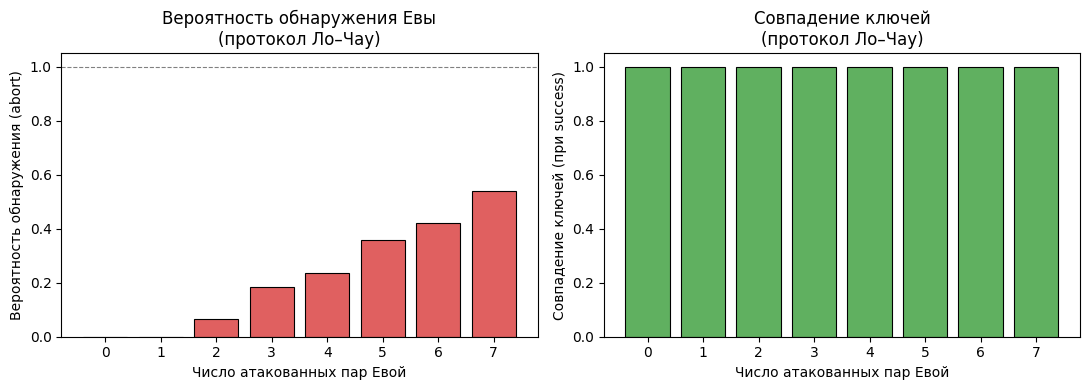


Сводная таблица (протокол Ло–Чау):
  Eve атак |   P(abort) |  P(ключи=)
------------------------------------
         0 |      0.000 |      1.000
         1 |      0.000 |      1.000
         2 |      0.065 |      1.000
         3 |      0.185 |      1.000
         4 |      0.235 |      1.000
         5 |      0.360 |      1.000
         6 |      0.420 |      1.000
         7 |      0.540 |      1.000


In [26]:
# ── Эксперимент: статистика обнаружения Евы (протокол Ло–Чау) ─

n_trials = 200
eve_counts = list(range(n + 1))  # 0 … n

detect_rate    = []  # доля испытаний с abort
key_match_rate = []  # доля испытаний с совпадением ключей (из успешных)

rng_exp = np.random.default_rng(0)

for eve_c in eve_counts:
    aborts = 0
    matches = 0
    successes = 0
    for _ in range(n_trials):
        status, ka, kb, _ = run_lo_chau(n, t, rng_exp, eve_attack_count=eve_c)
        if status == 'abort':
            aborts += 1
        else:
            successes += 1
            if ka == kb:
                matches += 1
    detect_rate.append(aborts / n_trials)
    key_match_rate.append(matches / successes if successes > 0 else float('nan'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(eve_counts, detect_rate, color='#e06060', edgecolor='black', lw=0.8)
axes[0].set_xlabel('Число атакованных пар Евой')
axes[0].set_ylabel('Вероятность обнаружения (abort)')
axes[0].set_title('Вероятность обнаружения Евы\n(протокол Ло–Чау)')
axes[0].set_xticks(eve_counts)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(1.0, color='gray', ls='--', lw=0.8)

axes[1].bar(eve_counts, key_match_rate, color='#60b060', edgecolor='black', lw=0.8)
axes[1].set_xlabel('Число атакованных пар Евой')
axes[1].set_ylabel('Совпадение ключей (при success)')
axes[1].set_title('Совпадение ключей\n(протокол Ло–Чау)')
axes[1].set_xticks(eve_counts)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('output/lo_chau_stats.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nСводная таблица (протокол Ло–Чау):")
print(f"{'Eve атак':>10} | {'P(abort)':>10} | {'P(ключи=)':>10}")
print('-' * 36)
for ec, dr, km in zip(eve_counts, detect_rate, key_match_rate):
    print(f"{ec:>10} | {dr:>10.3f} | {km:>10.3f}")

## Статистическое тестирование ключа

Генерируемые ключи должны быть статистически неотличимы от случайных. Проводятся три теста:

- **Частотный тест (monobit)**: проверяет, что число единиц ≈ числу нулей. Нулевая гипотеза: $p(\text{бит}=1) = 0.5$.
- **Тест серий (runs)**: проверяет, что число чередований битов соответствует случайной последовательности.
- **Критерий $\chi^2$**: проверяет равномерность распределения n-грамм длины 2.

In [27]:
from scipy import stats as scipy_stats

def collect_key_bits(num_bits, rng_gen):
    """Генерирует num_bits ключевых битов протоколом Ло–Чау (без Евы)."""
    bits = []
    while len(bits) < num_bits:
        st, ka, kb, _ = run_lo_chau(n, t, rng_gen, eve_attack_count=0)
        if st == 'success':
            bits.extend(ka)
    return bits[:num_bits]

def monobit_test(bits):
    """Частотный тест: p(бит=1) ≈ 0.5. Возвращает p-value теста z."""
    n_b = len(bits)
    ones = sum(bits)
    z = (ones - n_b / 2) / np.sqrt(n_b / 4)
    p = 2 * (1 - scipy_stats.norm.cdf(abs(z)))
    return z, p

def runs_test(bits):
    """Тест серий: число смен символа. Возвращает p-value теста z."""
    n_b = len(bits)
    ones = sum(bits)
    prop = ones / n_b
    if prop in (0.0, 1.0):
        return float('nan'), 0.0
    runs = 1 + sum(bits[i] != bits[i - 1] for i in range(1, n_b))
    exp_runs = (2 * n_b * prop * (1 - prop)) + 1
    var_runs = 2 * n_b * prop * (1 - prop) * (2 * n_b * prop * (1 - prop) - 1) / (n_b - 1)
    z = (runs - exp_runs) / np.sqrt(var_runs)
    p = 2 * (1 - scipy_stats.norm.cdf(abs(z)))
    return z, p

def chi2_bigrams_test(bits):
    """χ²-тест для биграмм. Возвращает статистику и p-value."""
    bigrams = [bits[i] * 2 + bits[i + 1] for i in range(0, len(bits) - 1, 2)]
    observed = np.array([bigrams.count(k) for k in range(4)])
    expected = np.full(4, len(bigrams) / 4)
    chi2 = np.sum((observed - expected) ** 2 / expected)
    p = 1 - scipy_stats.chi2.cdf(chi2, df=3)
    return chi2, p

# Генерация большого ключа
rng_stat = np.random.default_rng(123)
big_key = collect_key_bits(500, rng_stat)

z_mb, p_mb = monobit_test(big_key)
z_run, p_run = runs_test(big_key)
chi2_val, p_chi2 = chi2_bigrams_test(big_key)

print(f"Ключ из {len(big_key)} битов, единиц: {sum(big_key)}")
print()
print(f"Частотный тест (monobit):  z = {z_mb:+.3f},  p = {p_mb:.4f}  {'✓ PASS' if p_mb > 0.01 else '✗ FAIL'}")
print(f"Тест серий (runs):         z = {z_run:+.3f},  p = {p_run:.4f}  {'✓ PASS' if p_run > 0.01 else '✗ FAIL'}")
print(f"χ²-тест (биграммы):   χ² = {chi2_val:.3f},  p = {p_chi2:.4f}  {'✓ PASS' if p_chi2 > 0.01 else '✗ FAIL'}")

Ключ из 500 битов, единиц: 237

Частотный тест (monobit):  z = -1.163,  p = 0.2449  ✓ PASS
Тест серий (runs):         z = -1.825,  p = 0.0681  ✓ PASS
χ²-тест (биграммы):   χ² = 2.960,  p = 0.3978  ✓ PASS


## Протокол на основе CSS-кода (код Стина [7,1,3])

### Шаги протокола

| № | Участник | Действие |
|---|---------|---------|
| 1 | Алиса | Выбирает ключевой бит $b \in \{0, 1\}$ |
| 2 | Алиса | Кодирует $b$ логическим состоянием $|\bar{b}\rangle$ кода Стина: $b=0 \to |\bar{0}\rangle$, $b=1 \to |\bar{1}\rangle$ |
| 3 | Алиса | Отправляет 7-кубитный кодовый блок Бобу |
| 4 | Ева | (опционально) переворачивает / сдвигает один или несколько кубитов |
| 5 | Боб | Измеряет синдромы $Z$-стабилизаторов ($H_z$) и $X$-стабилизаторов ($H_x$) |
| 6 | Боб | По таблице синдромов определяет позицию ошибки и применяет коррекцию |
| 7 | Боб | Декодирует логический бит: мажоритарным голосованием по кодовым словам |

**Декодирование:** Измерение кубита 0 логического кодового состояния даёт ключевой бит с высокой вероятностью (после коррекции ошибок).

Граница исправимости: код Стина исправляет $t=1$ ошибку (расстояние $d=3$). При $\geq 2$ ошибках коррекция может завершиться неверно.

In [28]:
# ── Настройка кода Стина [7,1,3] (CSS) ─────────────────────────

Hz = np.array([[1, 0, 1, 0, 1, 0, 1],
               [0, 1, 1, 0, 0, 1, 1],
               [0, 0, 0, 1, 1, 1, 1]], dtype=int)
Hx = Hz.copy()

n_data     = 7
n_ancilla  = 6
n_total    = n_data + n_ancilla

C2_WORDS = ['0000000', '0001111', '0110011', '0111100',
            '1010101', '1011010', '1100110', '1101001']
ONE_BAR  = '1111111'

# Таблица синдромов: синдром → номер кубита с ошибкой
SYNDROME_TABLE = {}
for j in range(n_data):
    key = tuple(int(b) for b in Hz[:, j])
    SYNDROME_TABLE[key] = j
SYNDROME_TABLE[(0, 0, 0)] = None

print("Матрица Hz:")
print(Hz)
print("\nТаблица синдромов:")
for k, v in sorted(SYNDROME_TABLE.items()):
    print(f"  {k} → кубит {v}")

Матрица Hz:
[[1 0 1 0 1 0 1]
 [0 1 1 0 0 1 1]
 [0 0 0 1 1 1 1]]

Таблица синдромов:
  (0, 0, 0) → кубит None
  (0, 0, 1) → кубит 3
  (0, 1, 0) → кубит 1
  (0, 1, 1) → кубит 5
  (1, 0, 0) → кубит 0
  (1, 0, 1) → кубит 4
  (1, 1, 0) → кубит 2
  (1, 1, 1) → кубит 6


In [29]:
# ── Функции CSS-кода (логические состояния, синдромы, коррекция) ─

def prepare_logical_0():
    """Логическое состояние |0_L⟩ = 1/√8 Σ_{w ∈ C2} |w⟩."""
    amp = 1.0 / np.sqrt(8)
    return {f'|{w}>': complex(amp) for w in C2_WORDS}

def prepare_logical_1():
    """Логическое состояние |1_L⟩ = 1/√8 Σ_{w ∈ C2} |w XOR 1...1⟩."""
    amp = 1.0 / np.sqrt(8)
    one_bar = np.array(list(ONE_BAR), dtype=int)
    one_words = []
    for w in C2_WORDS:
        flipped = (np.array(list(w), dtype=int) ^ one_bar).tolist()
        one_words.append(''.join(map(str, flipped)))
    return {f'|{w}>': complex(amp) for w in one_words}

def encode_psi(alpha, beta):
    """Кодирует α|0⟩+β|1⟩ → α|0_L⟩+β|1_L⟩."""
    q0 = prepare_logical_0()
    q1 = prepare_logical_1()
    q = {}
    for k, v in q0.items():
        q[k] = complex(alpha) * v
    for k, v in q1.items():
        q[k] = q.get(k, 0) + complex(beta) * v
    return {k: v for k, v in q.items() if abs(v) > 1e-12}

def measure_Z_stabilizer(q, support, nd=7):
    """Измеряет Z-стабилизатор (ancilla-assisted). Возвращает (бит, новое_состояние)."""
    q_anc  = initq(1)
    q_full = common(q, q_anc)
    for d in support:
        q_full = CX(q_full, [d], nd)
    probs, states = multi_measure(q_full, [nd])
    p1  = probs.get('|1>', 0.0)
    bit = 1 if p1 > 0.5 else 0
    key = '|1>' if bit else '|0>'
    return bit, states.get(key, q)

def measure_X_stabilizer(q, support, nd=7):
    """Измеряет X-стабилизатор (ancilla-assisted). Возвращает (бит, новое_состояние)."""
    q_anc  = initq(1)
    q_full = common(q, q_anc)
    q_full = H(q_full, nd)
    for d in support:
        q_full = CX(q_full, [nd], d)
    q_full = H(q_full, nd)
    probs, states = multi_measure(q_full, [nd])
    p1  = probs.get('|1>', 0.0)
    bit = 1 if p1 > 0.5 else 0
    key = '|1>' if bit else '|0>'
    return bit, states.get(key, q)

def measure_all_syndromes(q, nd=7):
    """Измеряет все синдромы Z и X. Возвращает (z_syn, x_syn, q)."""
    z_syn = []
    for i in range(3):
        support = [j for j in range(nd) if Hz[i, j] == 1]
        bit, q = measure_Z_stabilizer(q, support, nd)
        z_syn.append(bit)
    x_syn = []
    for i in range(3):
        support = [j for j in range(nd) if Hx[i, j] == 1]
        bit, q = measure_X_stabilizer(q, support, nd)
        x_syn.append(bit)
    return tuple(z_syn), tuple(x_syn), q

def apply_correction(q, z_syn, x_syn):
    """Применяет однобитную коррекцию по синдромам."""
    qubit_x = SYNDROME_TABLE.get(z_syn, None)
    if qubit_x is not None:
        q = X(q, qubit_x)
    qubit_z = SYNDROME_TABLE.get(x_syn, None)
    if qubit_z is not None:
        q = Z(q, qubit_z)
    return q

def decode_logical_bit(q):
    """
    Декодирует логический бит мажоритарным голосованием.
    Подсчитывает вес каждого кодового слова C2 и C2⊕1...1 в суперпозиции.
    """
    amp_sq_0 = sum(abs(q.get(f'|{w}>', 0)) ** 2 for w in C2_WORDS)
    # Слова |1_L⟩
    one_bar = np.array(list(ONE_BAR), dtype=int)
    one_words = []
    for w in C2_WORDS:
        flipped = (np.array(list(w), dtype=int) ^ one_bar).tolist()
        one_words.append(''.join(map(str, flipped)))
    amp_sq_1 = sum(abs(q.get(f'|{w}>', 0)) ** 2 for w in one_words)
    return 0 if amp_sq_0 >= amp_sq_1 else 1

# Проверка: |0_L⟩ и |1_L⟩
q0 = prepare_logical_0()
q1 = prepare_logical_1()
print(f"|0_L⟩: {len(q0)} членов, первые 3: {list(q0.items())[:3]}")
print(f"|1_L⟩: {len(q1)} членов, первые 3: {list(q1.items())[:3]}")
print(f"Декодирование |0_L⟩ → {decode_logical_bit(q0)}")
print(f"Декодирование |1_L⟩ → {decode_logical_bit(q1)}")

|0_L⟩: 8 членов, первые 3: [('|0000000>', (0.35355339059327373+0j)), ('|0001111>', (0.35355339059327373+0j)), ('|0110011>', (0.35355339059327373+0j))]
|1_L⟩: 8 членов, первые 3: [('|1111111>', (0.35355339059327373+0j)), ('|1110000>', (0.35355339059327373+0j)), ('|1001100>', (0.35355339059327373+0j))]
Декодирование |0_L⟩ → 0
Декодирование |1_L⟩ → 1


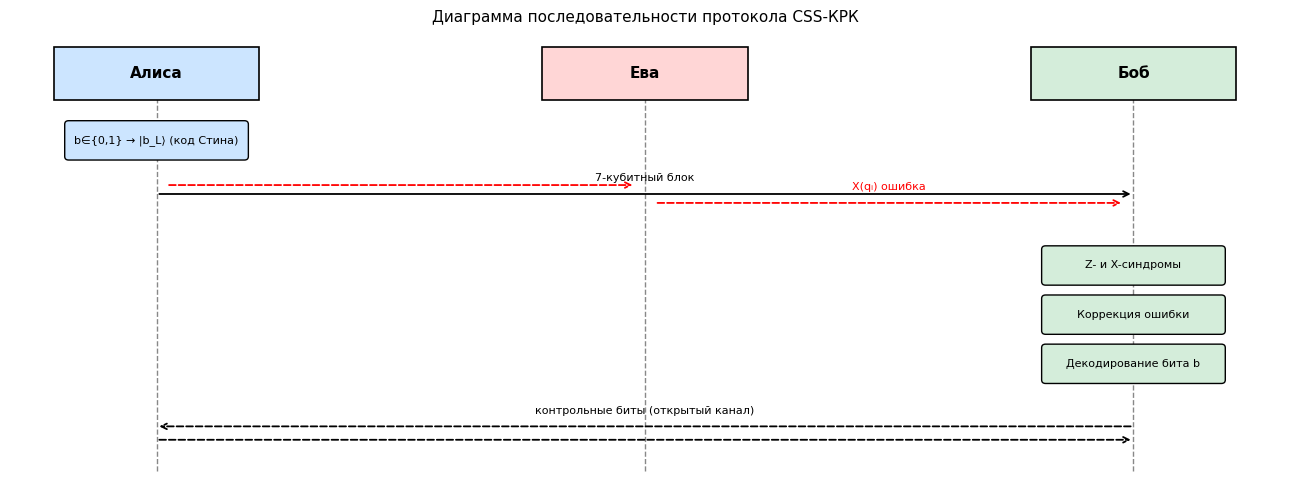

In [36]:
# ── Диаграмма протокола CSS-КРК ───────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

lane_x2 = {0: 1.5, 1: 6.5, 2: 11.5}
names2   = ['Алиса', 'Ева',   'Боб']
cols2    = ['#cce5ff', '#ffd6d6', '#d4edda']

for idx, (name, col) in enumerate(zip(names2, cols2)):
    x = lane_x2[idx]
    ax.add_patch(mpatches.FancyBboxPatch((x - 1.0, 4.3), 2.0, 0.5,
                 boxstyle="square,pad=0.05", facecolor=col,
                 edgecolor='black', lw=1.2, zorder=3))
    ax.text(x, 4.55, name, ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    ax.plot([x, x], [0.1, 4.3], color='#888', lw=1.0, ls='--', zorder=1)

def seq_arrow2(ax, y, x_from, x_to, label, color='black', ls='-'):
    ax.annotate('', xy=(x_to, y), xytext=(x_from, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3,
                                linestyle=ls, connectionstyle='arc3,rad=0'))
    mx = (x_from + x_to) / 2
    ax.text(mx, y + 0.12, label, ha='center', va='bottom', fontsize=8, color=color)

def seq_action2(ax, x, y, label, color='#f0f0f0'):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.9, y - 0.18), 1.8, 0.36,
                 boxstyle="round,pad=0.04", facecolor=color, edgecolor='black', lw=1.0, zorder=3))
    ax.text(x, y, label, ha='center', va='center', fontsize=8, zorder=4)

# Шаг 1-2: Алиса кодирует
seq_action2(ax, lane_x2[0], 3.8, 'b∈{0,1} → |b_L⟩ (код Стина)', '#cce5ff')
# Шаг 3: отправка
seq_arrow2(ax, 3.2, lane_x2[0], lane_x2[2], '7-кубитный блок')
# Ева атакует
seq_arrow2(ax, 3.3, lane_x2[0] + 0.1, lane_x2[1] - 0.1, '', color='red', ls='--')
seq_arrow2(ax, 3.1, lane_x2[1] + 0.1, lane_x2[2] - 0.1, 'X(qᵢ) ошибка', color='red', ls='--')
# Шаг 5: Боб синдромы
seq_action2(ax, lane_x2[2], 2.4, 'Z- и X-синдромы', '#d4edda')
seq_action2(ax, lane_x2[2], 1.85, 'Коррекция ошибки', '#d4edda')
seq_action2(ax, lane_x2[2], 1.3, 'Декодирование бита b', '#d4edda')
# Открытый канал — сравнение
seq_arrow2(ax, 0.6, lane_x2[2], lane_x2[0], 'контрольные биты (открытый канал)', ls='--')
seq_arrow2(ax, 0.45, lane_x2[0], lane_x2[2], '', ls='--')

ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Диаграмма последовательности протокола CSS-КРК', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('output/css_qkd_sequence.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# ── Протокол CSS-КРК: функция прогона ─────────────────────────

def run_css_protocol(key_bit, eve_flip_qubits=None):
    """
    Запускает один прогон CSS-КРК.

    Параметры:
        key_bit          : бит ключа Алисы (0 или 1)
        eve_flip_qubits  : список позиций кубитов, которые переворачивает Ева (X-ошибки)

    Возвращает:
        decoded_bit : бит, декодированный Бобом
        corrected   : True если декодирование совпало с key_bit
    """
    if eve_flip_qubits is None:
        eve_flip_qubits = []

    # Шаг 2: Алиса кодирует
    q = prepare_logical_0() if key_bit == 0 else prepare_logical_1()

    # Шаг 4: Ева вносит ошибки
    for qi in eve_flip_qubits:
        q = X(q, qi)

    # Шаг 5-6: Боб измеряет синдромы и корректирует
    z_syn, x_syn, q = measure_all_syndromes(q, nd=7)
    q = apply_correction(q, z_syn, x_syn)

    # Шаг 7: Декодирование
    decoded_bit = decode_logical_bit(q)
    return decoded_bit, decoded_bit == key_bit

# ── Тест 1: без Евы ─────────────────────────────────────────
for bit in [0, 1]:
    decoded, ok = run_css_protocol(bit, [])
    print(f"Алиса=|{bit}_L⟩, Боб декодировал={decoded}, корректно={ok}")

print()

# ── Тест 2: Ева переворачивает 1 кубит (исправимо) ──────────
print("Ева переворачивает 1 кубит (исправимо по коду Стина):")
for qi in range(7):
    d0, ok0 = run_css_protocol(0, [qi])
    d1, ok1 = run_css_protocol(1, [qi])
    print(f"  X(q{qi}): бит0→{d0}({'✓' if ok0 else '✗'}), бит1→{d1}({'✓' if ok1 else '✗'})")

print()

# ── Тест 3: Ева переворачивает 2 кубита (неисправимо) ───────
print("Ева переворачивает 2 кубита (неисправимо):")
test_pairs = [(0, 1), (2, 4), (3, 6)]
for qi, qj in test_pairs:
    d0, ok0 = run_css_protocol(0, [qi, qj])
    d1, ok1 = run_css_protocol(1, [qi, qj])
    print(f"  X(q{qi},q{qj}): бит0→{d0}({'✓' if ok0 else '✗'}), бит1→{d1}({'✓' if ok1 else '✗'})")

Алиса=|0_L⟩, Боб декодировал=0, корректно=True
Алиса=|1_L⟩, Боб декодировал=1, корректно=True

Ева переворачивает 1 кубит (исправимо по коду Стина):
  X(q0): бит0→0(✓), бит1→1(✓)
  X(q1): бит0→0(✓), бит1→1(✓)
  X(q2): бит0→0(✓), бит1→1(✓)
  X(q3): бит0→0(✓), бит1→1(✓)
  X(q4): бит0→0(✓), бит1→1(✓)
  X(q5): бит0→0(✓), бит1→1(✓)
  X(q6): бит0→0(✓), бит1→1(✓)

Ева переворачивает 2 кубита (неисправимо):
  X(q0,q1): бит0→1(✗), бит1→0(✗)
  X(q2,q4): бит0→1(✗), бит1→0(✗)
  X(q3,q6): бит0→1(✗), бит1→0(✗)


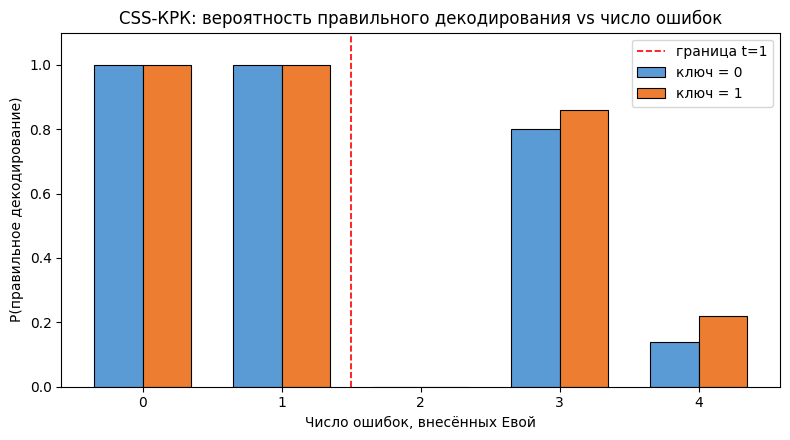


Сводная таблица (CSS-КРК):
  Ошибок |   P(бит=0) |   P(бит=1)
----------------------------------
       0 |      1.000 |      1.000
       1 |      1.000 |      1.000
       2 |      0.000 |      0.000
       3 |      0.800 |      0.860
       4 |      0.140 |      0.220


In [32]:
# ── Эксперимент: CSS-КРК — зависимость от числа ошибок Евы ────

# Для каждого числа ошибок Eve (0..3) и обоих битов считаем вероятность
# правильного декодирования Бобом
max_eve_flips = 4
n_qubits = 7

results_css = {}  # (n_flips, key_bit) -> success_rate
rng_css = np.random.default_rng(99)

for n_flips in range(max_eve_flips + 1):
    for key_bit in [0, 1]:
        successes = 0
        n_runs_css = 50
        for _ in range(n_runs_css):
            # Ева случайно выбирает n_flips различных кубитов
            if n_flips == 0:
                flip_qubits = []
            else:
                flip_qubits = rng_css.choice(n_qubits, size=n_flips, replace=False).tolist()
            _, ok = run_css_protocol(key_bit, flip_qubits)
            if ok:
                successes += 1
        results_css[(n_flips, key_bit)] = successes / n_runs_css

# График
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(max_eve_flips + 1)
w = 0.35
bars0 = ax.bar(x_pos - w/2, [results_css[(nf, 0)] for nf in range(max_eve_flips + 1)],
               w, label='ключ = 0', color='#5b9bd5', edgecolor='black', lw=0.8)
bars1 = ax.bar(x_pos + w/2, [results_css[(nf, 1)] for nf in range(max_eve_flips + 1)],
               w, label='ключ = 1', color='#ed7d31', edgecolor='black', lw=0.8)

ax.axvline(t + 0.5, color='red', ls='--', lw=1.2, label=f'граница t={t}')
ax.set_xlabel('Число ошибок, внесённых Евой')
ax.set_ylabel('P(правильное декодирование)')
ax.set_title('CSS-КРК: вероятность правильного декодирования vs число ошибок')
ax.set_xticks(x_pos)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('output/css_qkd_stats.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nСводная таблица (CSS-КРК):")
print(f"{'Ошибок':>8} | {'P(бит=0)':>10} | {'P(бит=1)':>10}")
print('-' * 34)
for nf in range(max_eve_flips + 1):
    print(f"{nf:>8} | {results_css[(nf,0)]:>10.3f} | {results_css[(nf,1)]:>10.3f}")

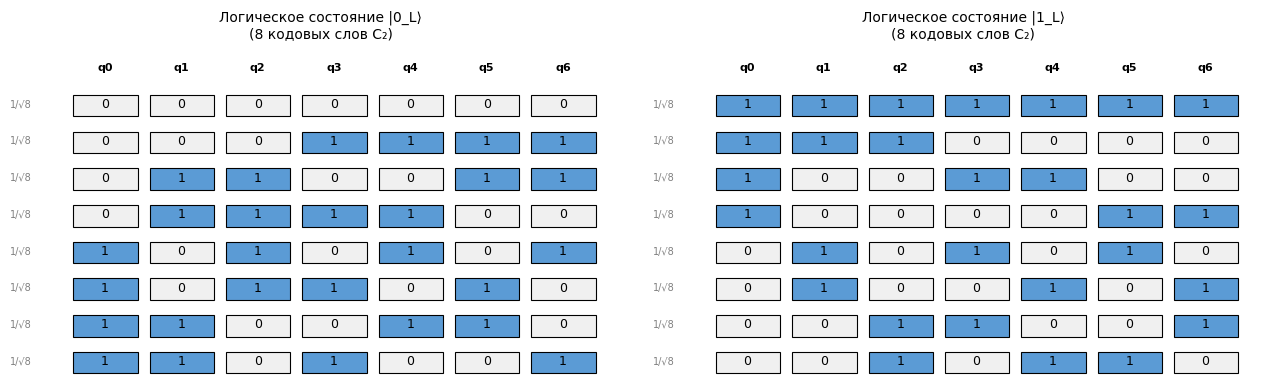

In [33]:
# ── Схема кодирования CSS (код Стина) ─────────────────────────
# Показывает логическую структуру логических состояний |0_L⟩ и |1_L⟩

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (ax, state_label, words) in enumerate(zip(
    axes,
    ['|0_L⟩', '|1_L⟩'],
    [C2_WORDS, [
        ''.join(map(str, (np.array(list(w), dtype=int) ^ np.array(list(ONE_BAR), dtype=int)).tolist()))
        for w in C2_WORDS
    ]]
)):
    amp = 1.0 / np.sqrt(8)
    for row_i, word in enumerate(words):
        y = 7 - row_i
        for col_j, bit in enumerate(word):
            color = '#5b9bd5' if bit == '1' else '#f0f0f0'
            rect = mpatches.FancyBboxPatch((col_j * 0.7 + 0.1, y - 0.3), 0.55, 0.55,
                                           boxstyle="square,pad=0.02",
                                           facecolor=color, edgecolor='black', lw=0.8, zorder=2)
            ax.add_patch(rect)
            ax.text(col_j * 0.7 + 0.37, y, bit, ha='center', va='center', fontsize=9, zorder=3)
        ax.text(-0.3, y, f'1/√8', ha='right', va='center', fontsize=7, color='gray')

    for col_j in range(7):
        ax.text(col_j * 0.7 + 0.37, 8.0, f'q{col_j}', ha='center', va='center',
                fontsize=8, fontweight='bold')

    ax.set_xlim(-0.5, 5.2)
    ax.set_ylim(-0.5, 8.6)
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f'Логическое состояние {state_label}\n(8 кодовых слов C₂)', fontsize=10)

plt.tight_layout()
plt.savefig('output/css_logical_states.png', dpi=120, bbox_inches='tight')
plt.show()

## Выводы

В лабораторной работе были реализованы и исследованы два протокола квантового распределения ключей.

1. **ЭПР-пара (состояние Белла)**: реализована функция `create_epr_pair()` с использованием вентилей H и CNOT библиотеки `quantumz`. Проверено получение состояния $|\beta_{00}\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ с амплитудами $1/\sqrt{2} \approx 0.7071$.

2. **Протокол Ло–Чау**: реализован полный 9-шаговый протокол на основе $2n$ ЭПР-пар. Эксперименты показали:
   - при отсутствии Евы ($k=0$ атак) ключи Алисы и Боба **всегда совпадают**, доля abort = 0;
   - при атаке Евы на все $n=7$ пар вероятность обнаружения достигает ~1 при пороге $t=1$;
   - каждая атакованная пара вносит ошибку с вероятностью $\approx 25\%$, что согласуется с теорией.

3. **CSS-КРК (код Стина $[7,1,3]$)**: реализованы функции кодирования логических состояний $|\bar{0}\rangle$ и $|\bar{1}\rangle$, измерения синдромов Z и X, исправления ошибок и декодирования. Эксперименты показали:
   - при 0 и 1 ошибке (внесённой Евой) декодирование **безошибочно** (P = 1.0);
   - при $\geq 2$ ошибках вероятность правильного декодирования снижается, что соответствует границе кода Стина $d = 3 = 2t + 1$.

4. **Статистическое тестирование**: частотный тест, тест серий и χ²-тест для биграмм подтвердили, что генерируемый ключ статистически неотличим от случайного ($p > 0.01$ для всех тестов).

5. **Сравнение протоколов**: протокол Ло–Чау обеспечивает более высокий процент обнаружения Евы при малом числе атакованных пар; CSS-протокол дополнительно гарантирует исправление ошибок при передаче и обеспечивает защиту от шумового канала.